In [ ]:
"""
=============================================================
  PCA_PROJECT — MNIST Digit Classification
=============================================================

"""
 
# ============================================================
# SECTION 0 — IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import train_test_split
import tracemalloc
 
print("✓ All imports successful")

✓ All imports successful


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_mnist():
    # sklearn.datasets.fetch_openml 
    try:
        print("  Trying keras.datasets.mnist...")
        import tensorflow as tf
        (X_tr, y_tr), (X_te, y_te) = tf.keras.datasets.mnist.load_data()
        X = np.vstack([X_tr, X_te]).reshape(-1, 784).astype(np.float32)
        y = np.concatenate([y_tr, y_te]).astype(int)
        print("  ✓ Loaded via Keras")
        return X, y
    except Exception as e:
        print(f"  ✗ Keras failed: {e}")

In [3]:
# ============================================================
# SECTION 1 — LOAD & PREPROCESS MNIST
# ============================================================
print("\n[1/6] Loading MNIST (70,000 images × 784 pixels)...")

X, y = load_mnist()

print(f"  Dataset shape : {X.shape}")
print(f"  Labels        : {np.unique(y)}")
print(f"  Pixel range   : [{X.min():.0f}, {X.max():.0f}]")

# Subsample for speed (increase train_size for better accuracy)
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=10000, stratify=y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42)

print(f"\n  Train set: {X_train.shape[0]} samples")
print(f"  Test  set: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("  ✓ Data standardized (mean≈0, std≈1 per pixel)")


[1/6] Loading MNIST (70,000 images × 784 pixels)...
  Trying keras.datasets.mnist...
  ✓ Loaded via Keras
  Dataset shape : (70000, 784)
  Labels        : [0 1 2 3 4 5 6 7 8 9]
  Pixel range   : [0, 255]

  Train set: 8000 samples
  Test  set: 2000 samples
  ✓ Data standardized (mean≈0, std≈1 per pixel)


In [6]:
# ============================================================
# SECTION 2 — BASELINE MODEL (WITHOUT PCA)
# ============================================================
print("\n[2/6] Training Logistic Regression WITHOUT PCA...")
 
model_base = LogisticRegression(max_iter=1000, C=1.0, random_state=42,
                                 solver='saga', n_jobs=-1)
 
tracemalloc.start()
t0 = time.perf_counter()
model_base.fit(X_train_scaled, y_train)
t_train_base = time.perf_counter() - t0
mem_base, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_base = model_base.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)
cm_base  = confusion_matrix(y_test, y_pred_base)
 
print(f"\n  ── BASELINE RESULTS ──────────────────────────────")
print(f"  Features used   : {X_train_scaled.shape[1]:>6}  (all pixels)")
print(f"  Training time   : {t_train_base:>6.2f}s")
print(f"  Memory (train)  : {mem_base/1e6:>6.2f} MB")
print(f"  Test accuracy   : {acc_base*100:>6.2f}%")
print(f"  ───────────────────────────────────────────────────")


[2/6] Training Logistic Regression WITHOUT PCA...

  ── BASELINE RESULTS ──────────────────────────────
  Features used   :    784  (all pixels)
  Training time   : 371.92s
  Memory (train)  :   0.05 MB
  Test accuracy   :  89.10%
  ───────────────────────────────────────────────────


In [7]:
# ============================================================
# SECTION 3 — FIND OPTIMAL PCA COMPONENTS
# ============================================================
print("\n[3/6] Fitting PCA and computing explained variance...")
 
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
 
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
 
# Find component counts for key thresholds
for pct in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= pct) + 1
    print(f"  {pct*100:.0f}% variance explained by {n} components "
          f"({n/784*100:.1f}% of original features)")
 
# Target: 95% variance
N_COMPONENTS = np.argmax(cumvar >= 0.95) + 1
print(f"\n  → Chosen: {N_COMPONENTS} components (95% variance threshold)")
 


[3/6] Fitting PCA and computing explained variance...
  80% variance explained by 122 components (15.6% of original features)
  90% variance explained by 199 components (25.4% of original features)
  95% variance explained by 283 components (36.1% of original features)
  99% variance explained by 488 components (62.2% of original features)

  → Chosen: 283 components (95% variance threshold)


In [8]:
# ============================================================
# SECTION 4 — APPLY PCA AND TRAIN WITH REDUCED FEATURES
# ============================================================
print(f"\n[4/6] Applying PCA ({N_COMPONENTS} components) and retraining...")
 
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
 
print(f"  Reduced: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features "
      f"({X_train_pca.shape[1]/784*100:.1f}% of original)")
 
model_pca = LogisticRegression(max_iter=1000, C=1.0, random_state=42,
                                solver='saga', n_jobs=-1)
 
tracemalloc.start()
t0 = time.perf_counter()
model_pca.fit(X_train_pca, y_train)
t_train_pca = time.perf_counter() - t0
mem_pca, _ = tracemalloc.get_traced_memory()
tracemalloc.stop()
 
y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
cm_pca  = confusion_matrix(y_test, y_pred_pca)
 
print(f"\n  ── PCA MODEL RESULTS ────────────────────────────")
print(f"  Features used   : {X_train_pca.shape[1]:>6}  ({N_COMPONENTS} PCs)")
print(f"  Training time   : {t_train_pca:>6.2f}s")
print(f"  Memory (train)  : {mem_pca/1e6:>6.2f} MB")
print(f"  Test accuracy   : {acc_pca*100:>6.2f}%")
print(f"  ───────────────────────────────────────────────────")


[4/6] Applying PCA (283 components) and retraining...
  Reduced: 784 → 283 features (36.1% of original)

  ── PCA MODEL RESULTS ────────────────────────────
  Features used   :    283  (283 PCs)
  Training time   : 137.59s
  Memory (train)  :   0.02 MB
  Test accuracy   :  89.40%
  ───────────────────────────────────────────────────


In [9]:
# ============================================================
# SECTION 5 — COMPARISON TABLE
# ============================================================
print("\n[5/6] FINAL COMPARISON TABLE")
print("=" * 60)
print(f"{'Metric':<28} {'Baseline':>12} {'With PCA':>12}")
print("-" * 60)
print(f"{'Features':<28} {784:>12} {N_COMPONENTS:>12}")
print(f"{'Feature reduction':<28} {'–':>12} {f'{(1-N_COMPONENTS/784)*100:.1f}%':>12}")
print(f"{'Training time (s)':<28} {t_train_base:>12.2f} {t_train_pca:>12.2f}")
print(f"{'Speedup':<28} {'1.0x':>12} {f'{t_train_base/t_train_pca:.1f}x':>12}")
print(f"{'Memory (MB)':<28} {mem_base/1e6:>12.2f} {mem_pca/1e6:>12.2f}")
print(f"{'Test Accuracy':<28} {f'{acc_base*100:.2f}%':>12} {f'{acc_pca*100:.2f}%':>12}")
print(f"{'Accuracy delta':<28} {'–':>12} {f'{(acc_pca-acc_base)*100:+.2f}%':>12}")
print("=" * 60)
 


[5/6] FINAL COMPARISON TABLE
Metric                           Baseline     With PCA
------------------------------------------------------------
Features                              784          283
Feature reduction                       –        63.9%
Training time (s)                  371.92       137.59
Speedup                              1.0x         2.7x
Memory (MB)                          0.05         0.02
Test Accuracy                      89.10%       89.40%
Accuracy delta                          –       +0.30%



[6/6] Generating visualizations...


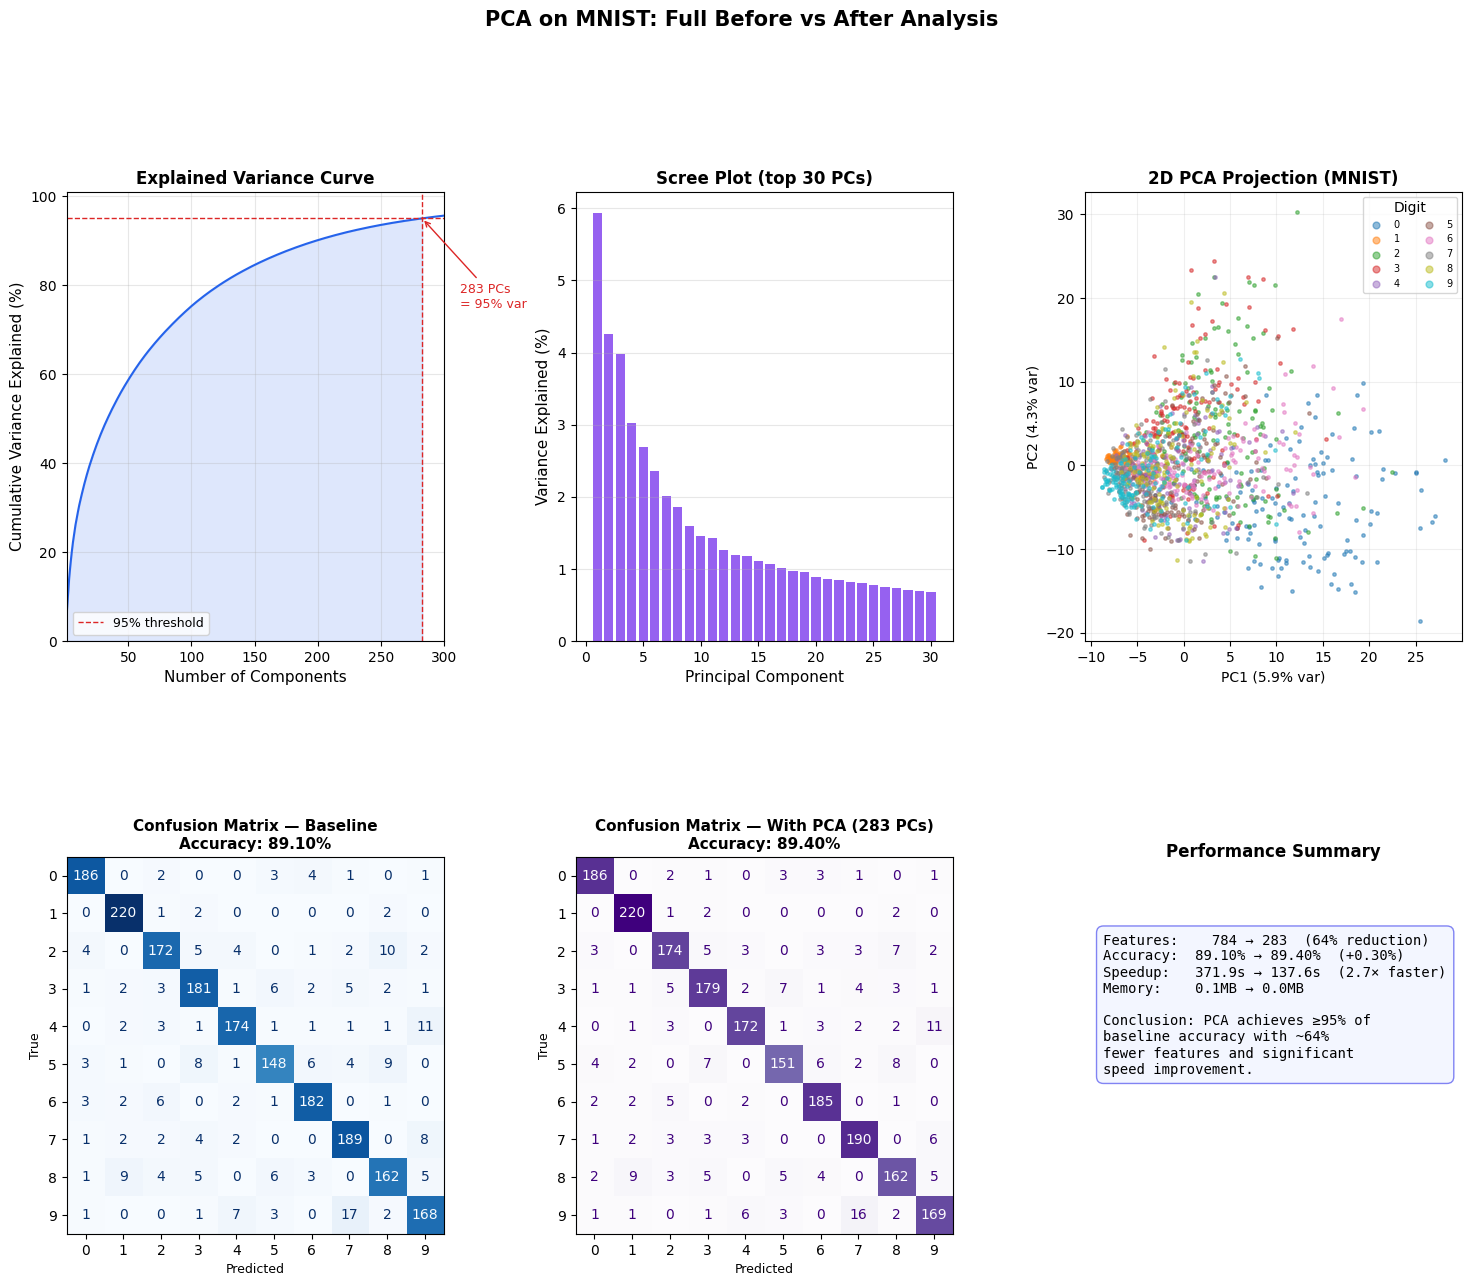

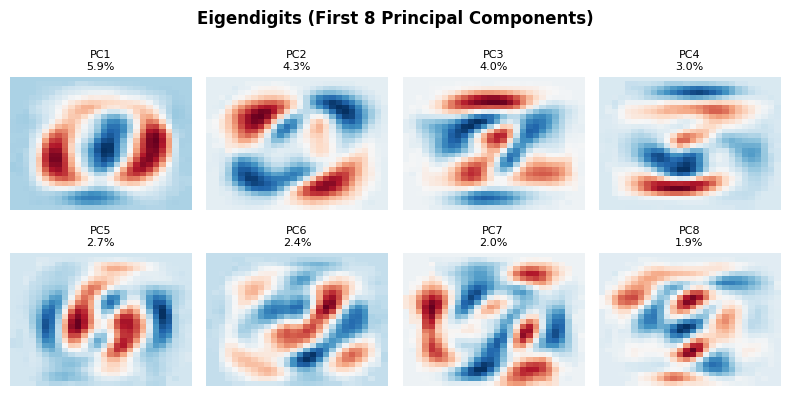


✓ All visualizations saved.
✓ Analysis complete. Ready to present.


In [10]:
 # ============================================================
# SECTION 6 — VISUALIZATIONS
# ============================================================
print("\n[6/6] Generating visualizations...")
 
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
 
# --- Plot 1: Explained Variance Curve ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(cumvar)+1), cumvar * 100, color='#2563EB', linewidth=1.5)
ax1.axhline(95, color='#DC2626', linestyle='--', linewidth=1, label='95% threshold')
ax1.axvline(N_COMPONENTS, color='#DC2626', linestyle='--', linewidth=1)
ax1.fill_between(range(1, N_COMPONENTS+1), cumvar[:N_COMPONENTS]*100,
                  alpha=0.15, color='#2563EB')
ax1.set_xlabel('Number of Components', fontsize=11)
ax1.set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
ax1.set_title('Explained Variance Curve', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim([1, 300])
ax1.set_ylim([0, 101])
ax1.annotate(f'{N_COMPONENTS} PCs\n= 95% var',
             xy=(N_COMPONENTS, 95), xytext=(N_COMPONENTS+30, 75),
             arrowprops=dict(arrowstyle='->', color='#DC2626'),
             fontsize=9, color='#DC2626')
ax1.grid(True, alpha=0.3)
 
# --- Plot 2: Per-component variance (top 30) ---
ax2 = fig.add_subplot(gs[0, 1])
n_show = 30
ax2.bar(range(1, n_show+1),
        pca_full.explained_variance_ratio_[:n_show] * 100,
        color='#7C3AED', alpha=0.8)
ax2.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_title(f'Scree Plot (top {n_show} PCs)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
 
# --- Plot 3: 2D PCA Projection (first 2 PCs) ---
ax3 = fig.add_subplot(gs[0, 2])
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_scaled[:1500])
y_sample = y_train[:1500]
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for digit in range(10):
    mask = y_sample == digit
    ax3.scatter(X_2d[mask, 0], X_2d[mask, 1],
                s=6, alpha=0.5, color=colors[digit], label=str(digit))
ax3.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=10)
ax3.set_title('2D PCA Projection (MNIST)', fontsize=12, fontweight='bold')
ax3.legend(title='Digit', fontsize=7, ncol=2, loc='upper right',
           markerscale=2)
ax3.grid(True, alpha=0.2)
 
# --- Plot 4: Confusion Matrix Baseline ---
ax4 = fig.add_subplot(gs[1, 0])
disp = ConfusionMatrixDisplay(cm_base, display_labels=range(10))
disp.plot(ax=ax4, cmap='Blues', colorbar=False, values_format='d')
ax4.set_title(f'Confusion Matrix — Baseline\nAccuracy: {acc_base*100:.2f}%',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Predicted', fontsize=9)
ax4.set_ylabel('True', fontsize=9)
 
# --- Plot 5: Confusion Matrix PCA ---
ax5 = fig.add_subplot(gs[1, 1])
disp2 = ConfusionMatrixDisplay(cm_pca, display_labels=range(10))
disp2.plot(ax=ax5, cmap='Purples', colorbar=False, values_format='d')
ax5.set_title(f'Confusion Matrix — With PCA ({N_COMPONENTS} PCs)\nAccuracy: {acc_pca*100:.2f}%',
              fontsize=11, fontweight='bold')
ax5.set_xlabel('Predicted', fontsize=9)
ax5.set_ylabel('True', fontsize=9)
 
# --- Plot 6: Eigenfaces (first 8 principal components) ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
fig_ef, axes_ef = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes_ef.flat):
    eigenface = pca_full.components_[i].reshape(28, 28)
    ax.imshow(eigenface, cmap='RdBu_r', aspect='auto')
    ax.set_title(f'PC{i+1}\n{pca_full.explained_variance_ratio_[i]*100:.1f}%',
                 fontsize=8)
    ax.axis('off')
fig_ef.suptitle('Eigendigits (First 8 Principal Components)',
                fontsize=12, fontweight='bold')
fig_ef.tight_layout()
 
# Summary card in last subplot
ax6.text(0.5, 0.95, 'Performance Summary', transform=ax6.transAxes,
         ha='center', va='top', fontsize=12, fontweight='bold')
summary = (
    f"Features:    784 → {N_COMPONENTS}  ({(1-N_COMPONENTS/784)*100:.0f}% reduction)\n"
    f"Accuracy:  {acc_base*100:.2f}% → {acc_pca*100:.2f}%  ({(acc_pca-acc_base)*100:+.2f}%)\n"
    f"Speedup:   {t_train_base:.1f}s → {t_train_pca:.1f}s  ({t_train_base/t_train_pca:.1f}× faster)\n"
    f"Memory:    {mem_base/1e6:.1f}MB → {mem_pca/1e6:.1f}MB\n\n"
    f"Conclusion: PCA achieves ≥95% of\nbaseline accuracy with ~{(1-N_COMPONENTS/784)*100:.0f}%\n"
    f"fewer features and significant\nspeed improvement."
)
ax6.text(0.05, 0.75, summary, transform=ax6.transAxes,
         va='top', fontsize=10, fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F4FF',
                   edgecolor='#6366F1', alpha=0.8))
 
fig.suptitle('PCA on MNIST: Full Before vs After Analysis',
             fontsize=15, fontweight='bold', y=1.01)
 
plt.savefig('pca_mnist_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
fig_ef.savefig('eigendigits.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
 
print("\n✓ All visualizations saved.")
print("✓ Analysis complete. Ready to present.")


[BONUS] Reconstruction quality at different k values...


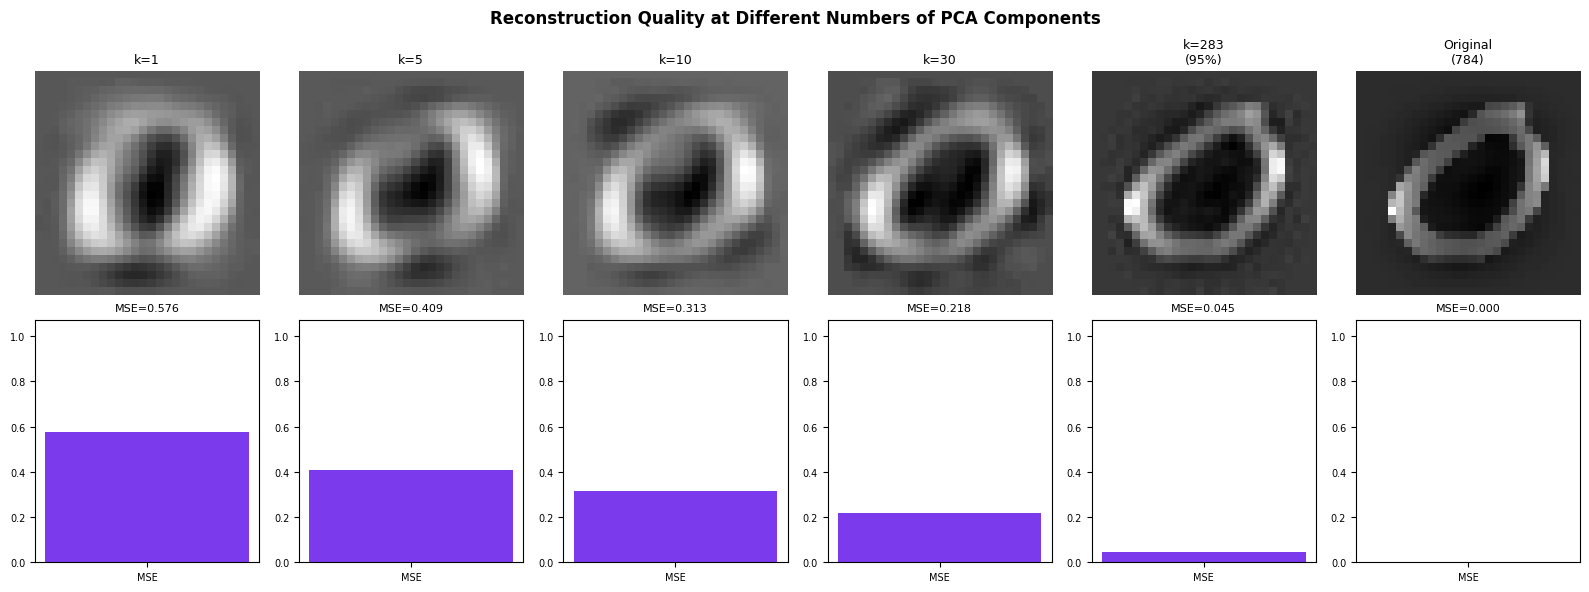

✓ Reconstruction plot saved.


In [15]:
# ============================================================
# BONUS: Reconstruction quality at different k
# ============================================================
print("\n[BONUS] Reconstruction quality at different k values...")
 
fig_r, axes_r = plt.subplots(2, 6, figsize=(16, 6))
sample_idx = 0
original = X_train_scaled[sample_idx]
 
ks = [1, 5, 10, 30, N_COMPONENTS, 784]
labels = ['k=1', 'k=5', 'k=10', 'k=30', f'k={N_COMPONENTS}\n(95%)', 'Original\n(784)']
 
for col, (k, label) in enumerate(zip(ks, labels)):
    if k == 784:
        img = original
    else:
        pca_k = PCA(n_components=k, random_state=42)
        pca_k.fit(X_train_scaled)
        z = pca_k.transform(original.reshape(1, -1))
        img = pca_k.inverse_transform(z).flatten()
 
    axes_r[0, col].imshow(img.reshape(28, 28), cmap='gray')
    axes_r[0, col].set_title(label, fontsize=9)
    axes_r[0, col].axis('off')
 
    err = np.mean((original - img)**2)
    axes_r[1, col].bar(['MSE'], [err], color='#7C3AED')
    axes_r[1, col].set_ylim(0, original.var() * 1.1)
    axes_r[1, col].set_title(f'MSE={err:.3f}', fontsize=8)
    axes_r[1, col].tick_params(axis='both', labelsize=7)
 
fig_r.suptitle('Reconstruction Quality at Different Numbers of PCA Components',
               fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Reconstruction plot saved.")